In [32]:
import random
import dill 
import datetime as dt
import glob 
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import pandas as pd
import scipy.spatial as spatial
import sys 
wd=".."
sys.path.append(wd+'//CPN//')
import numpy as np 
import statsmodels.api as sm
from tqdm import tqdm_notebook, tqdm
import brokenaxes

In [33]:
## A series of functions to parse the  simulation output
def get_run_uuid(sim_output, **kwargs):
    sim_id, sim_data = sim_output
    return(sim_id['uuid'])

def get_run_random_seed(sim_output, **kwargs):
    '''
    '''
    sim_ids, sim_data = sim_output
    random_seed = sim_ids['np.random.seed']
    return(random_seed)

def get_num_echoes_heard(sim_output, **kwargs):
    '''
    '''
    sim_ids, sim_data = sim_output
    num_echoes_heard = np.sum(sim_data[0])
    return(num_echoes_heard)

which_echo = {True: 1 , False:0}

def get_echoids(sim_data, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    echo_indices = np.argwhere(sim_data[0]==which_echo[heard]).flatten()
    return(echo_indices)    

def get_echo_levels(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output
    echo_ids = get_echoids(sim_data, **kwargs)
    
    echo_levels = sim_data[1]['target_echoes'].loc[echo_ids,'level']
    return(echo_levels)
    

def get_group_size(sim_output, **kwargs):
    ''' This function is necessary because of the
    stupid way I stored the parameter sets using classes
    '''
    sim_ids, sim_data = sim_output
    num_bats_in_group = sim_data[0].size +1 
    return(num_bats_in_group)

def split_by_groupsize(df):
    all_subdfs = []
    group_sizes = np.unique(df['groupsize'])
    for each_groupsize in group_sizes:
        subdf = df[df['groupsize']==each_groupsize]
        all_subdfs.append(subdf)
    return(group_sizes, all_subdfs)



def get_individual_positions(sim_output, **kwargs):
    '''
    '''
    sim_ids, sim_data = sim_output
    _, _b, geometry = sim_data
    positions = geometry['positions']
    return(positions)


def get_detection_distance(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output 
    echo_inds = get_echoids(sim_data, **kwargs)
    individuals_inds = echo_inds +1 # because focal individ is 0 index
    all_positions = get_individual_positions(sim_output)
    heard_individual_positions = all_positions[individuals_inds,:]
    focal_ind = all_positions[0,:]
    distances = spatial.distance
    
    positions_of_relevance = np.row_stack((focal_ind, heard_individual_positions))
    distances = spatial.distance_matrix(positions_of_relevance, 
                                        positions_of_relevance)[1:,0]
    return(distances)

def get_detection_azimuth(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output 
    echo_inds = get_echoids(sim_data, **kwargs)
    
    echoes_heard, sounds, geom = sim_data
    echoes = sounds['target_echoes']
    echo_azimuth = np.array(echoes['theta'][echo_inds])
    
    return(echo_azimuth)


def get_echo_levels(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output 
    echo_inds = get_echoids(sim_data, **kwargs)
    
    echoes_heard, sounds, geom = sim_data
    echoes = sounds['target_echoes']
    echo_level = np.array(echoes['level'][echo_inds])
    
    return(echo_level)
    


def get_nearest_neighbour_distances(sim_output, **kwargs):
    '''Extract the distance to the nearest neighbour of the focal bat
    
    Parameters
    -----------
    sim_output : output from a simulation run. 
    
    Keyword Arguments
    ------------------
    nearest_nbrs : int.
                    The number of distance measurements given. 
                    Defaults to 5. 


    Returns
    ---------
    nearest_neighbour_distances : 1 x nearest_nbrs np.array
    '''
    nearest_nbrs = kwargs.get('nearest_nbrs',5)
    positions = get_individual_positions(sim_output)
    distances = spatial.distance_matrix(positions, positions)[1:,0]
    nearest_neighbour_distances = np.sort(distances)[:nearest_nbrs]
    return(nearest_neighbour_distances)

def get_furthest_bat2bat_distance(sim_output, **kwargs):
    '''
    '''
    positions = get_individual_positions(sim_output)
    distances = spatial.distance_matrix(positions, positions)
    furthest_distance = np.max(distances)
    return(furthest_distance)
    

def extract_parameter_values(one_sim_result, **kwargs):
    '''
    Extracts the variables from the simulation result
    by extracting the values from the 
    'parameter set'
    
    Parameters
    -----------
    one_sim_results : tuple/list with 2 entries. 
                      entry 1 should have the simulation identifiers
                      entry 2 may be anything.
    Keyword Arguments
    -----------------
    variables_to_extract : list with str.
                           The names of the variables that are to be extracted.
                           Notes: 
                           If 'source_level' is one of the variables - only the 
                           emitted levels as dBSPL is output - the reference distance
                           is *ignored*.

    Returns
    --------
    param_set : list.
                A list with the numeric or Boolean values of each of the variables extracted. 
    '''
    sim_identifiers, sim_data = one_sim_result
    all_parameter_values = sim_identifiers['parameter_set']
    
    param_set_for_this_run = []
    for each in kwargs['variables_to_extract']:
        if each != 'source_level':
            param_set_for_this_run.append(all_parameter_values[each])
        elif each == 'source_level':
            param_set_for_this_run.append(all_parameter_values[each]['dBSPL'])
    
    return(param_set_for_this_run)
        
make_to_string = lambda X: str(X)

def join_all_parameters(parameter_list):
    '''
    '''
    params_as_string = map(make_to_string, parameter_list)
    param_joined = '*'.join(params_as_string)
    return(param_joined)

def make_paramset_id(sim_output, **kwargs):
    '''
    '''
    all_parameter_values = extract_parameter_values(sim_output, **kwargs)
    param_id = join_all_parameters(all_parameter_values)
    return(param_id)


def load_simresult(path_to_simresult):
    '''
    '''
    with open(path_to_simresult, 'rb') as sim:
        output = dill.load(sim)
    return(output)

def load_and_extract(simresult_path, extraction_functions, **kwargs):
    '''
    Parameters
    ----------
    simresult_path : str/path object

    extraction_functions : list/tuple with one or more function that work on 
                            the simulation output

    Keyword Arguments
    -----------------
    As defined by the extraction functions. 
    Every key must be unique and correspond to a particular extraction function!

    Returns
    ---------
    extracted_output : object type thats returned by the extraction function
    '''
    simresult = load_simresult(simresult_path)
    extracted_outputs = [ extract(simresult, **kwargs) for extract in extraction_functions]
    return(extracted_outputs)

In [34]:
# Some functions that deal with formatting the simulation data after it's been loaded from the csv file. 

def format_nearest_neighbour_distances(nearest_nbr_entry):
    '''
    Parameters
    ----------
    nearest_nbr_entry : string. 
                        pd.DataFrame column entry with 
                        the following format 
                        '[<float>, <float>, <float>]'
    
    Returns
    -------
    np.array
    
    '''
    only_float_as_string = nearest_nbr_entry[1:-1]
    all_strings_separated = only_float_as_string.split()
    floats = map(lambda X : float(X), all_strings_separated)
    
    distances = np.array(floats)
    return(distances)
    
def split_parameters_joint_to_separate_columns(row, col_names):
    for colnam, value in zip(col_names, row['parameters_joint']):
        row[colnam] = value
    return(row)


In [35]:
results_folder = wd+'/simulation_results//'
folder_id= "/non_central_0.75/"
list_of_folder_ids= glob.glob(results_folder+"*")
list_of_folder_ids= [i[22:] for i in list_of_folder_ids]
list_of_folder_ids= np.sort(list_of_folder_ids)
# glob.glob(results_folder+"*")
list_of_folder_ids

array(['central', 'non_central_0.2', 'non_central_0.5',
       'non_central_0.75', 'non_central_1'], dtype='<U16')

In [36]:
folder_id= list_of_folder_ids[0]
all_results = glob.glob(results_folder+folder_id+'/*.simresults')
some_results =random.sample(all_results, int(len(all_results)*1.0))

In [37]:
list_of_folder_ids

array(['central', 'non_central_0.2', 'non_central_0.5',
       'non_central_0.75', 'non_central_1'], dtype='<U16')

In [38]:
extraction_fns = [get_num_echoes_heard, get_group_size, get_furthest_bat2bat_distance,
                 get_nearest_neighbour_distances, get_detection_distance, get_run_uuid,
                  get_run_random_seed,make_paramset_id, extract_parameter_values,
                 get_echo_levels, get_detection_azimuth]
keyword_arguments = {'nearest_nbrs':3}

In [39]:
keyword_arguments['variables_to_extract'] = ['heading_variation', 'echocall_duration','atmospheric_attenuation','min_spacing','source_level',
                        'interpulse_interval', 'implement_shadowing',
                                            ]

In [40]:
what_to_do = input('Do you want to "rerun" from scratch or 2, "reanalyse" from previous data')

In [41]:
if what_to_do == 'rerun':
    super_array = []
    for folder_id in list_of_folder_ids:
        all_results = glob.glob(results_folder+folder_id+'/*.simresults')
        some_results =random.sample(all_results, int(len(all_results)*1.0))
        
        %time extracted_simdata = Parallel(n_jobs=4)(delayed(load_and_extract)(each, extraction_fns, **keyword_arguments) for each in tqdm(some_results))
        # print(extracted_simdata)
        echoes_heard = []
        group_size = []
        group_diameter = []
        nearest_3nbrs = []
        nbr_detection_range = []
        uuid = []
        seed = []
        param_ids = []
        parameter_values = []
        echo_levels = []
        detection_angle = []
        for each in extracted_simdata:
            for variable, list_to_append in zip(each, [echoes_heard, group_size, group_diameter,
                                                    nearest_3nbrs, nbr_detection_range,
                                                    uuid, seed, param_ids, parameter_values,
                                                    echo_levels, detection_angle]):
                list_to_append.append(variable)
        simulation_data = pd.DataFrame(data = {'nbrs_detected':echoes_heard,
                                        'group_size':group_size,
                                        'group_diameter':group_diameter,
                                        'nearest_neighbour_distance':nearest_3nbrs,
                                        'nbrs_detected_distance':nbr_detection_range,
                                        'uuid':uuid,
                                        'seed':seed,
                                        'paramset_id':param_ids,
                                        'parameters_joint':parameter_values,
                                        'echo_levels':echo_levels,
                                        'detection_azimuth':detection_angle})
        column_names = keyword_arguments['variables_to_extract']

        for each in column_names:
            simulation_data[each] = np.nan

        %time simulation_data = simulation_data.apply(split_parameters_joint_to_separate_columns, 1, col_names=column_names)    
        yyyymmdd = dt.datetime.now()
        timestamp = str([yyyymmdd.year,yyyymmdd.month,yyyymmdd.day,yyyymmdd.hour])
        ##### thanks to https://realpython.com/fast-flexible-pandas/#but-i-heard-that-pandas-is-slow
        data_store = pd.HDFStore('groupsize_data'+timestamp+'.h5')
        data_store['simulation_data'] = simulation_data
        data_store.close()

        super_array.append(simulation_data)

100%|██████████| 1505/1505 [00:01<00:00, 1014.00it/s]
/tmp/ipykernel_10263/1490462937.py:47: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


CPU times: user 376 ms, sys: 8.35 ms, total: 384 ms
Wall time: 1.93 s
CPU times: user 83.1 ms, sys: 0 ns, total: 83.1 ms
Wall time: 83.1 ms


100%|██████████| 4000/4000 [00:03<00:00, 1215.20it/s]


CPU times: user 403 ms, sys: 19.9 ms, total: 423 ms
Wall time: 3.7 s
CPU times: user 205 ms, sys: 1.87 ms, total: 207 ms
Wall time: 206 ms


/tmp/ipykernel_10263/1490462937.py:47: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data
100%|██████████| 4000/4000 [00:03<00:00, 1237.79it/s]


...

/tmp/ipykernel_10263/1490462937.py:47: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


CPU times: user 209 ms, sys: 1.79 ms, total: 211 ms
Wall time: 211 ms


100%|██████████| 4000/4000 [00:03<00:00, 1245.59it/s]


CPU times: user 390 ms, sys: 19.9 ms, total: 409 ms
Wall time: 3.63 s
CPU times: user 310 ms, sys: 0 ns, total: 310 ms
Wall time: 310 ms


/tmp/ipykernel_10263/1490462937.py:47: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


In [42]:
super_array[1]

,nbrs_detected,group_size,group_diameter,nearest_neighbour_distance,nbrs_detected_distance,uuid,seed,paramset_id,parameters_joint,echo_levels,detection_azimuth,heading_variation,echocall_duration,atmospheric_attenuation,min_spacing,source_level,interpulse_interval,implement_shadowing
0,4,5,1.319643,"[0.6060252068469918, 0.6209302350054599, 0.965...","[0.6060252068469918, 0.9939929520098614, 0.620...",9293a625-0cb6-4898-ba19-5c749916d678,592264943,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[47.56428381856845, 46.21875553262829, 57.7377...","[172.603, 139.3662, 112.7793, -136.557]",10,0.0025,-1,0.5,100,0.1,True
1,3,5,1.228216,"[0.6403167173115738, 0.9158849199475895, 0.985...","[0.6403167173115738, 0.9856388217004919, 1.228...",eb77ef5b-716e-4517-b72a-8ab5309697a3,12148156,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[59.7048006256685, 45.099052963338096, 42.4737...","[121.9519, 154.1042, 125.6632]",10,0.0025,-1,0.5,100,0.1,True
2,6,30,3.620727,"[0.528689491148304, 0.5332367928394562, 0.5549...","[0.528689491148304, 0.8675091240945215, 0.5332...",99212e76-422a-4757-ac59-06e43a83e507,870676314,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[69.25228394115226, 61.767448719276096, 49.796...","[80.6844, 29.008, -172.1555, -56.3128, -122.71...",10,0.0025,-1,0.5,100,0.1,True
3,4,5,1.333930,"[0.5767887674424298, 0.9282401602568338, 0.996...","[0.5767887674424298, 0.9966412940032854, 0.928...",a7617a42-351f-4495-98fb-5c2af140dd4d,710873060,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[69.37980782881837, 59.18520569936221, 55.9593...","[21.1626, -5.544, 68.911, 37.5202]",10,0.0025,-1,0.5,100,0.1,True
4,8,10,2.280230,"[0.5340646441315633, 0.5580870387974458, 0.703...","[0.5580870387974458, 0.7789836130035812, 1.162...",cb2cde2f-db02-457b-9773-a398588deadf,456152289,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[48.982238028271794, 52.31139519155818, 42.237...","[-173.3088, -123.5314, -154.029, 125.9372, 158...",10,0.0025,-1,0.5,100,0.1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,6,30,3.696848,"[0.5392149863000414, 0.5699439447048947, 0.650...","[0.5392149863000414, 1.2289147913694292, 0.905...",929d699d-fabb-4f06-a64e-cd9a85f59bc2,438533020,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[69.89706654257604, 55.16577381451823, 61.7895...","[0.9796, -17.6196, 68.2396, -72.0768, -77.6038...",10,0.0025,-1,0.5,100,0.1,True
3996,11,30,3.816283,"[0.6108394309676772, 0.6552809522902884, 0.721...","[0.7790665168968121, 0.7219001153074802, 0.831...",cca9e37c-cbc6-46e1-9eb2-94be43d33b6a,434015171,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[51.71567525681059, 65.75424582793211, 42.2197...","[128.1979, 68.0109, -167.3517, 94.8593, 67.560...",10,0.0025,-1,0.5,100,0.1,True
3997,4,5,1.306792,"[0.5052826049493185, 0.8396880996216839, 0.877...","[0.5052826049493185, 0.877732936973455, 0.8396...",dd23ff61-2790-4fa0-be18-27db21fe99a5,614996137,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[71.65307379953295, 62.942616535408995, 61.824...","[21.617, 63.9411, -35.1228, 10.2557]",10,0.0025,-1,0.5,100,0.1,True
3998,0,50,4.999574,"[0.5231670063802663, 0.5459349309677418, 0.588...",[],06226753-9a1d-46da-a041-567ab9ce2488,324018646,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]",[],[],10,0.0025,-1,0.5,100,0.1,True


In [43]:
cropped_data_set= []
i=0
for simulation_data in super_array:
    
    mask= simulation_data["group_size"] == int(100)
    simulation_data= simulation_data[~mask]
    mask= simulation_data["group_size"] == int(200)
    simulation_data= simulation_data[~mask]
    cropped_data_set.append(simulation_data)

cropped_data_set[2]

,nbrs_detected,group_size,group_diameter,nearest_neighbour_distance,nbrs_detected_distance,uuid,seed,paramset_id,parameters_joint,echo_levels,detection_azimuth,heading_variation,echocall_duration,atmospheric_attenuation,min_spacing,source_level,interpulse_interval,implement_shadowing
0,3,30,4.091101,"[0.5636400826791871, 0.6356877769429164, 0.774...","[1.0250505597439503, 0.5636400826791871, 0.824...",4bc841ba-84ca-45ab-99db-ac26839d48d8,895737038,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[58.73857635839288, 66.38081093881412, 62.1566...","[-74.237, -56.3012, -16.2568]",10,0.0025,-1,0.5,100,0.1,True
1,4,5,1.530950,"[0.8578862479869397, 1.3050314750343925, 1.514...","[0.8578862479869397, 1.5140262518855396, 1.305...",cb20de79-6b9a-4875-a0fd-1329b945ab96,729030139,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[61.827779254691684, 50.271131471475854, 54.42...","[1.6852, -5.4187, 32.131, 13.6616]",10,0.0025,-1,0.5,100,0.1,True
2,4,50,5.001331,"[0.5792670022356169, 0.688026088400538, 0.7159...","[0.8446750283560539, 0.851240713608685, 0.5792...",b0faddb8-8c8d-47e6-bf64-4dc73e1e306f,817373984,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[62.89122680933451, 62.38307299077793, 68.5862...","[68.9315, 24.9856, -31.4978, -69.3423]",10,0.0025,-1,0.5,100,0.1,True
3,1,75,5.814562,"[0.5256480650670652, 0.5339658514528504, 0.557...",[1.1516877420164058],fea3ed3f-4d7a-4cc0-b75e-49260a7eaf80,945539289,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]",[57.40524419810779],[-69.6134],10,0.0025,-1,0.5,100,0.1,True
4,9,10,1.889978,"[0.8099289762903351, 0.8183834577549782, 0.842...","[0.8423602414834765, 1.2450692100017642, 1.373...",7268053c-a52b-4691-8f9e-54628ffbf0f6,163061825,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[61.10661849600665, 55.26062187105386, 51.8598...","[-27.8485, -8.5704, -32.4029, -79.434, -61.791...",10,0.0025,-1,0.5,100,0.1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,6,30,3.812465,"[0.5128582832327623, 0.5514932252483087, 0.768...","[0.7838378933376827, 0.9366293638805447, 1.450...",1d994cb4-e7b0-4d8f-860b-87f4ad80db18,33550482,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[62.67120471737957, 61.075268136092554, 52.670...","[23.2133, -18.983, 4.8121, 92.3307, -103.1408,...",10,0.0025,-1,0.5,100,0.1,True
3996,4,30,3.814674,"[0.5011113942661983, 0.608950628734792, 0.6460...","[0.6460102685430096, 0.5011113942661983, 0.871...",3ed724e1-c82a-49ae-b86e-9e947a33ebb7,661935016,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[63.05101200722443, 60.58921429176716, 61.4570...","[-63.3764, 118.9578, -8.9575, 64.0153]",10,0.0025,-1,0.5,100,0.1,True
3997,1,75,6.027634,"[0.5033966373743893, 0.5070802818980676, 0.580...",[0.5033966373743893],966d5e12-1c14-402c-8c9e-377006a6c13c,238397969,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]",[71.6241144322466],[23.186],10,0.0025,-1,0.5,100,0.1,True
3998,1,30,3.679061,"[0.5327307612055395, 0.6965397970965124, 0.844...",[0.5327307612055395],aaccb770-447c-4774-b39b-956bb74b726d,479764410,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]",[70.10674795191309],[1.1463],10,0.0025,-1,0.5,100,0.1,True


In [44]:
type(simulation_data["group_size"][0])

numpy.int64

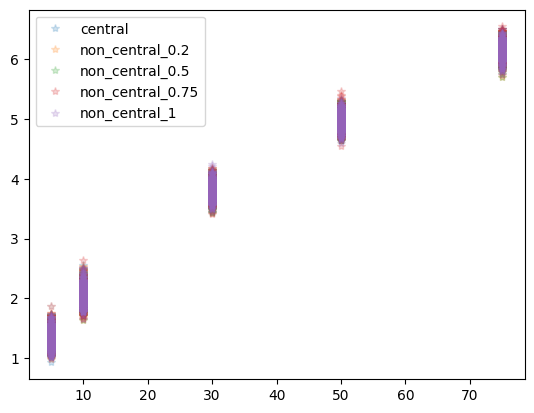

In [45]:
%matplotlib inline
i=0
for simulation_data in cropped_data_set:
    plt.plot(simulation_data['group_size'],
                simulation_data['group_diameter'], 
            '*', label=list_of_folder_ids[i], alpha=0.2)
    i+=1
plt.legend()
plt.show()

In [46]:
cropped_data_set[1]

,nbrs_detected,group_size,group_diameter,nearest_neighbour_distance,nbrs_detected_distance,uuid,seed,paramset_id,parameters_joint,echo_levels,detection_azimuth,heading_variation,echocall_duration,atmospheric_attenuation,min_spacing,source_level,interpulse_interval,implement_shadowing
0,4,5,1.319643,"[0.6060252068469918, 0.6209302350054599, 0.965...","[0.6060252068469918, 0.9939929520098614, 0.620...",9293a625-0cb6-4898-ba19-5c749916d678,592264943,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[47.56428381856845, 46.21875553262829, 57.7377...","[172.603, 139.3662, 112.7793, -136.557]",10,0.0025,-1,0.5,100,0.1,True
1,3,5,1.228216,"[0.6403167173115738, 0.9158849199475895, 0.985...","[0.6403167173115738, 0.9856388217004919, 1.228...",eb77ef5b-716e-4517-b72a-8ab5309697a3,12148156,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[59.7048006256685, 45.099052963338096, 42.4737...","[121.9519, 154.1042, 125.6632]",10,0.0025,-1,0.5,100,0.1,True
2,6,30,3.620727,"[0.528689491148304, 0.5332367928394562, 0.5549...","[0.528689491148304, 0.8675091240945215, 0.5332...",99212e76-422a-4757-ac59-06e43a83e507,870676314,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[69.25228394115226, 61.767448719276096, 49.796...","[80.6844, 29.008, -172.1555, -56.3128, -122.71...",10,0.0025,-1,0.5,100,0.1,True
3,4,5,1.333930,"[0.5767887674424298, 0.9282401602568338, 0.996...","[0.5767887674424298, 0.9966412940032854, 0.928...",a7617a42-351f-4495-98fb-5c2af140dd4d,710873060,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[69.37980782881837, 59.18520569936221, 55.9593...","[21.1626, -5.544, 68.911, 37.5202]",10,0.0025,-1,0.5,100,0.1,True
4,8,10,2.280230,"[0.5340646441315633, 0.5580870387974458, 0.703...","[0.5580870387974458, 0.7789836130035812, 1.162...",cb2cde2f-db02-457b-9773-a398588deadf,456152289,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[48.982238028271794, 52.31139519155818, 42.237...","[-173.3088, -123.5314, -154.029, 125.9372, 158...",10,0.0025,-1,0.5,100,0.1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,6,30,3.696848,"[0.5392149863000414, 0.5699439447048947, 0.650...","[0.5392149863000414, 1.2289147913694292, 0.905...",929d699d-fabb-4f06-a64e-cd9a85f59bc2,438533020,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[69.89706654257604, 55.16577381451823, 61.7895...","[0.9796, -17.6196, 68.2396, -72.0768, -77.6038...",10,0.0025,-1,0.5,100,0.1,True
3996,11,30,3.816283,"[0.6108394309676772, 0.6552809522902884, 0.721...","[0.7790665168968121, 0.7219001153074802, 0.831...",cca9e37c-cbc6-46e1-9eb2-94be43d33b6a,434015171,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[51.71567525681059, 65.75424582793211, 42.2197...","[128.1979, 68.0109, -167.3517, 94.8593, 67.560...",10,0.0025,-1,0.5,100,0.1,True
3997,4,5,1.306792,"[0.5052826049493185, 0.8396880996216839, 0.877...","[0.5052826049493185, 0.877732936973455, 0.8396...",dd23ff61-2790-4fa0-be18-27db21fe99a5,614996137,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[71.65307379953295, 62.942616535408995, 61.824...","[21.617, 63.9411, -35.1228, 10.2557]",10,0.0025,-1,0.5,100,0.1,True
3998,0,50,4.999574,"[0.5231670063802663, 0.5459349309677418, 0.588...",[],06226753-9a1d-46da-a041-567ab9ce2488,324018646,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]",[],[],10,0.0025,-1,0.5,100,0.1,True


In [47]:
simulation_data.keys()

Index(['nbrs_detected', 'group_size', 'group_diameter',
       'nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid', 'seed',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'heading_variation', 'echocall_duration', 'atmospheric_attenuation',
       'min_spacing', 'source_level', 'interpulse_interval',
       'implement_shadowing'],
      dtype='object')

In [48]:
by_minspacing = simulation_data.groupby('min_spacing')
nearest_nbr_dist = {}
for spacing, df in by_minspacing:
    nearest_nbr_distances = df['nearest_neighbour_distance'].reset_index(drop=True)
    nearest_nbr_dist[spacing] = np.concatenate(nearest_nbr_distances)
nearest_nbr_dists_for_plot = [nearest_nbr_dist[0.5]]

/tmp/ipykernel_10263/1379796575.py:9: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for groupsize, dataframe in data_by_groupsize:
/tmp/ipykernel_10263/1379796575.py:9: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for groupsize, dataframe in data_by_groupsize:
/tmp/ipykernel_10263/1379796575.py:9: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for groupsize, dataframe in data_by_groupsize:
/tmp/ipykernel_10263/1379796575.py:9: FutureWarning: In a future version of pandas

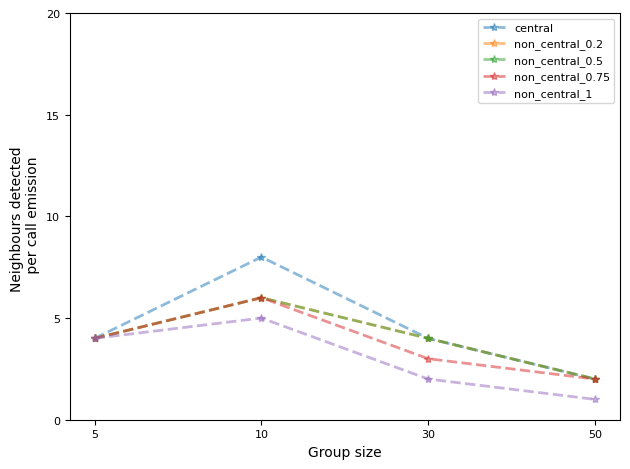

In [53]:
i=0
for simulation_data in cropped_data_set:
        data_by_groupsize = simulation_data.groupby(['group_size'])
        nbrs_detected_data = {}
        nbrs_detected_data['num_nbrs'] = []
        nbrs_detected_data['median_num_nbrs'] = []
        nbrs_detected_data['90%ile_num_nbrs'] = []
        groupsizes= []
        for groupsize, dataframe in data_by_groupsize:
                groupsizes.append(groupsize)
                nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
                nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
                nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))

        breakup_x_axis  = np.arange(1,len(groupsizes)+1)+0.5
        nbrs_detected_data['median_num_nbrs']

        # plt.figure(figsize=(7,3.42))
        # plt.violinplot(nbrs_detected_data['num_nbrs'][:-1], showextrema=False)
        plt.plot(np.arange(1,len(groupsizes)),nbrs_detected_data['median_num_nbrs'][:-1],
                '--*',linewidth=2, alpha=0.5,label=list_of_folder_ids[i])#'median')
        # plt.plot(np.arange(1,len(groupsizes)), nbrs_detected_data['90%ile_num_nbrs'][:-1],
        #         '--.',linewidth=2, alpha=0.5, label='90%ile')
        #plt.vlines(breakup_x_axis, -1,20, 'w',linewidth=30,alpha=1.0)
        plt.yticks(np.arange(0,21,5),fontsize=8)
        plt.xticks(range(1,len(groupsizes)),groupsizes[:-1],
                fontsize=8)
        plt.legend(fontsize=8)
        plt.ylabel('Neighbours detected \n per call emission', fontsize=10)
        plt.xlabel('Group size', fontsize=10)
        plt.ylim(0,20)
        plt.tight_layout()
        i+=1
        # plt.savefig('Figure2_groupsize_1200dpi.pdf',
        #         bbox_inches='tight', pad_inches=0.05, format='pdf', dpi=1200)